# Fraud Detection on BankSim Transactions

## Project Overview

This project develops a machine learning system to detect fraudulent transactions using the **BankSim synthetic banking dataset**.

The system analyzes customer transaction behavior and identifies anomalies that may indicate fraudulent activity.

Unlike traditional fraud detection systems that only output a binary prediction, this project introduces a **dual scoring framework**:

- **Fraud Likelihood** – probability that a transaction is fraudulent
- **Detection Confidence** – reliability of the fraud prediction based on behavioral consistency

This approach helps distinguish between isolated anomalies and persistent suspicious behavior.

# Dataset Description

### BankSim Dataset Overview

The dataset contains **594,643 transaction records** with **10 features** describing customer transactions and whether the transaction was fraudulent.

* **Rows:** 594,643 transactions
* **Columns:** 10 variables
* **Memory usage:** ~45.4 MB

Each row represents a **single financial transaction**.

---

### Data Types

The dataset includes three types of variables:

| Data Type                       | Columns                                                                          | Description                                              |
| ------------------------------- | -------------------------------------------------------------------------------- | -------------------------------------------------------- |
| **Integer (int64)**             | `step`, `fraud`                                                                  | Numerical discrete values                                |
| **Float (float64)**             | `amount`                                                                         | Continuous numerical value                               |
| **Object (categorical/string)** | `customer`, `age`, `gender`, `zipcodeOri`, `merchant`, `zipMerchant`, `category` | Categorical attributes describing users and transactions |

Most columns are **categorical variables**, which will require **encoding** before applying machine learning models.

---

### Feature Description

* **step** – Time step representing the order of transactions (simulated time units).
* **customer** – Unique identifier for the customer making the transaction.
* **age** – Age group category of the customer.
* **gender** – Customer gender.
* **zipcodeOri** – Zip code of the customer's location.
* **merchant** – Merchant identifier where the transaction occurred.
* **zipMerchant** – Merchant's zip code.
* **category** – Type of transaction (e.g., shopping category).
* **amount** – Transaction amount.
* **fraud** – Target variable indicating whether the transaction is fraudulent.

  * `0` = Legitimate transaction
  * `1` = Fraudulent transaction

---

### Summary Statistics

Key numerical insights from the dataset:

| Metric | Step  | Amount  | Fraud |
| ------ | ----- | ------- | ----- |
| Mean   | 94.99 | 37.89   | 0.012 |
| Std    | 51.05 | 111.40  | 0.109 |
| Min    | 0     | 0       | 0     |
| Median | 97    | 26.90   | 0     |
| Max    | 179   | 8329.96 | 1     |

**Observations:**

* The **average transaction amount is about 37.89**, but the **maximum amount reaches 8329.96**, indicating the presence of **large outlier transactions**.
* The **fraud rate is approximately 1.21%**, meaning the dataset is **highly imbalanced**, with fraudulent transactions being rare compared to legitimate ones.

---

### Missing Values

The dataset contains **no missing values** in any column.

| Column      | Missing Values |
| ----------- | -------------- |
| All columns | 0              |

This means **no imputation is required during preprocessing**.

---

### Initial Insights

* The dataset is **large and suitable for machine learning models**.
* Fraud cases represent **a very small proportion (≈1.2%)**, so techniques such as **class balancing, SMOTE, or specialized evaluation metrics (F1-score, ROC-AUC, Recall)** will be important.
* Several **categorical features** (`customer`, `merchant`, `category`, etc.) must be **encoded before modeling**.

---


## IEEE-CIS Dataset Overview

The dataset contains **590,540 transaction records** and **434 features** used for fraud detection. Each row represents a **single online transaction**, and the goal is to predict whether the transaction is **fraudulent (`isFraud = 1`) or legitimate (`isFraud = 0`)**.

* **Rows:** 590,540 transactions
* **Columns:** 434 features
* **Target Variable:** `isFraud`

This dataset is highly dimensional and contains **transaction information, card details, behavioral features, and device data**.

---

## Key Variables

### 1. Transaction Information

| Feature            | Description                                      |
| ------------------ | ------------------------------------------------ |
| **TransactionID**  | Unique identifier for each transaction           |
| **isFraud**        | Target variable (0 = legitimate, 1 = fraudulent) |
| **TransactionDT**  | Time of transaction from a reference start time  |
| **TransactionAmt** | Amount of the transaction                        |
| **ProductCD**      | Product code representing transaction type       |

These features describe **when and how a transaction occurred**.

---

### 2. Card and Payment Information

| Feature           | Description                |
| ----------------- | -------------------------- |
| **card1 – card6** | Payment card attributes    |
| **addr1, addr2**  | Billing region information |
| **dist1, dist2**  | Distance-related variables |

These variables provide **information about the payment method and geographical details**, which may help identify suspicious behavior.

---

### 3. Email Domain Features

| Feature           | Description            |
| ----------------- | ---------------------- |
| **P_emaildomain** | Purchaser email domain |
| **R_emaildomain** | Recipient email domain |

These features can reveal **patterns associated with fraudulent email domains**.

---

### 4. Transaction Behavior Features

| Feature Group | Description                                    |
| ------------- | ---------------------------------------------- |
| **C1 – C14**  | Count-based transaction features               |
| **D1 – D15**  | Time-based transaction features                |
| **M1 – M9**   | Matching indicators for transaction attributes |

These features represent **behavioral signals and transaction history patterns**, which are often useful for fraud detection.

---

### 5. V-Series Features (V1 – V339)

The **V features** are anonymized variables derived from complex feature engineering techniques applied by the dataset creators.

* They represent **transaction patterns, behavioral signals, and engineered attributes**.
* The exact meaning of these variables is not disclosed to protect sensitive financial information.
* These features are often **highly predictive for machine learning models**.

---

### 6. Identity Features

| Feature Group     | Description                             |
| ----------------- | --------------------------------------- |
| **id_01 – id_38** | Device and identity attributes          |
| **DeviceType**    | Type of device used (mobile or desktop) |
| **DeviceInfo**    | Device model or browser information     |

These variables help detect fraud based on **device fingerprints and identity characteristics**.

---

## Data Challenges

This dataset presents several challenges:

### High Dimensionality

With **434 features**, feature selection and dimensionality reduction techniques may be necessary to improve model performance and reduce overfitting.

### Missing Values

Many columns contain **missing values**, especially in the identity and V-series features. Proper handling strategies such as **imputation or dropping highly sparse columns** are required.

### Class Imbalance

Fraudulent transactions represent only a **small fraction of the dataset**, which makes the classification problem **imbalanced**. Special evaluation metrics such as **Precision, Recall, F1-score, and ROC-AUC** are more appropriate than accuracy.

### Complex Feature Relationships

Many features represent **behavioral patterns and aggregated statistics**, requiring careful preprocessing and feature engineering.

---

## Initial Insight

The dataset combines **transaction data, payment information, behavioral signals, and device fingerprints**, making it suitable for advanced machine learning models such as **Random Forest, Gradient Boosting, or XGBoost** for fraud detection.


# Import Libraries

This section imports the necessary Python libraries used throughout the project.

Key libraries include:

- **pandas / numpy** for data manipulation
- **matplotlib / seaborn** for visualization
- **scikit-learn** for machine learning models

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Optional: handling class imbalance
from sklearn.utils import resample

# Visualization style
sns.set(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to better understand the dataset and identify potential issues.

Key analysis steps include:

- Checking dataset structure
- Inspecting data types
- Analyzing statistical distributions
- Observing fraud class imbalance

Understanding these characteristics helps guide feature engineering and model selection.

## EDA for BankSim Dataset

In [2]:
# Load Dataset

# Unload the dataset from the zip file
import zipfile

with zipfile.ZipFile("../../bs140513_032310.zip", 'r') as zip_ref:
    zip_ref.extractall("../data")


#Load dataset
df = pd.read_csv("../data/bs140513_032310.csv")

In [3]:
# Basic dataset overview
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()

print("\nSummary statistics:")
display(df.describe())

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (594643, 10)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  object 
 2   age          594643 non-null  object 
 3   gender       594643 non-null  object 
 4   zipcodeOri   594643 non-null  object 
 5   merchant     594643 non-null  object 
 6   zipMerchant  594643 non-null  object 
 7   category     594643 non-null  object 
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 45.4+ MB

Summary statistics:


,step,amount,fraud
count,594643.000000,594643.000000,594643.000000
mean,94.986827,37.890135,0.012108
std,51.053632,111.402831,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000



Missing values per column:
step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64


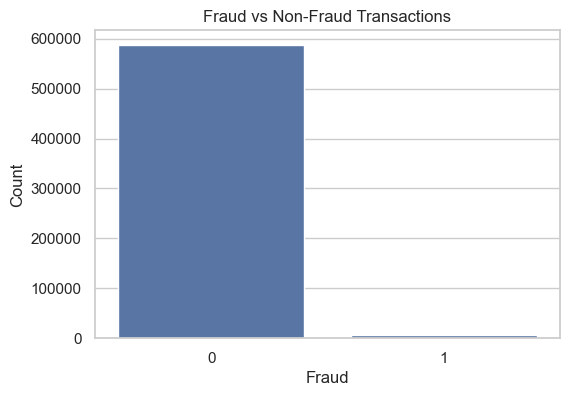

Fraud percentage distribution:
fraud
0    98.789189
1     1.210811
Name: proportion, dtype: float64


In [4]:
# Fraud distribution
plt.figure(figsize=(6,4))
sns.countplot(x='fraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

# Percentage distribution
fraud_percent = df['fraud'].value_counts(normalize=True) * 100
print("Fraud percentage distribution:")
print(fraud_percent)

### 1. Fraud vs Non-Fraud Transactions

This bar chart shows the distribution of **fraudulent and non-fraudulent transactions** in the dataset.

* Class **0** represents legitimate transactions.
* Class **1** represents fraudulent transactions.

**Observation:**

The dataset is **highly imbalanced**. The vast majority of transactions are legitimate, while fraudulent transactions represent only a **very small percentage (~1.2%)** of the total dataset.

**Implication:**

Because of this imbalance, standard accuracy may be misleading when evaluating models. Metrics such as **Precision, Recall, F1-score, and ROC-AUC** should be used, and techniques like **SMOTE, class weighting, or resampling** may be required.

---

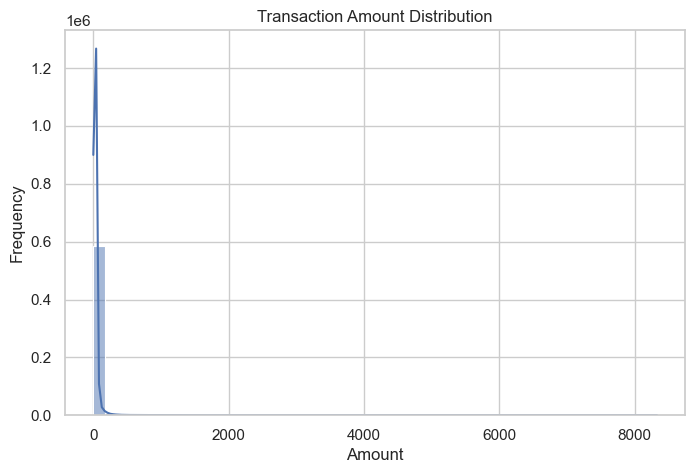

In [5]:
# Transaction amount distribution
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

### 2. Transaction Amount Distribution

This histogram shows the **distribution of transaction amounts** across all transactions.

**Observation:**

* Most transactions occur at **lower amounts**.
* The distribution is **heavily right-skewed**, meaning a small number of transactions have very large values.
* The maximum transaction amount reaches **over 8000**, indicating the presence of **outliers**.

**Implication:**

The skewed distribution can negatively affect some machine learning models, making **log transformation** useful to normalize the data.

---

In [6]:
df['amount_log'] = np.log1p(df['amount'])

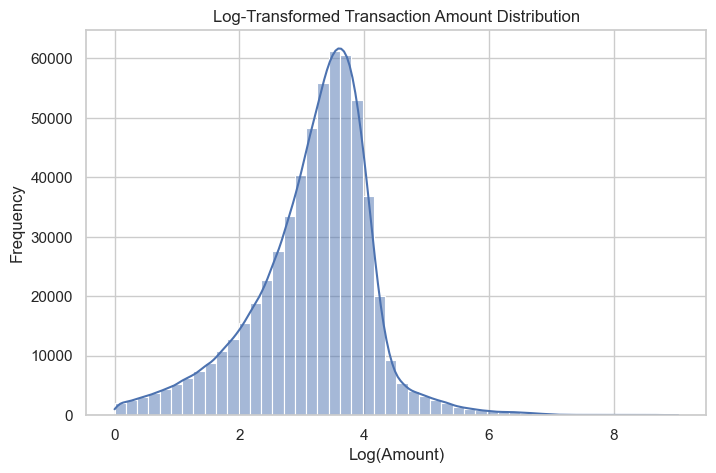

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount_log'], bins=50, kde=True)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("Log(Amount)")
plt.ylabel("Frequency")
plt.show()

### 3. Log-Transformed Transaction Amount Distribution

This histogram shows the distribution of **log-transformed transaction amounts**.

**Observation:**

After applying the logarithmic transformation:

* The distribution becomes **more symmetric and closer to a normal distribution**.
* Extreme outliers are compressed.

**Implication:**

Log transformation helps stabilize variance and improves the performance of machine learning algorithms that assume **normally distributed features**.

---

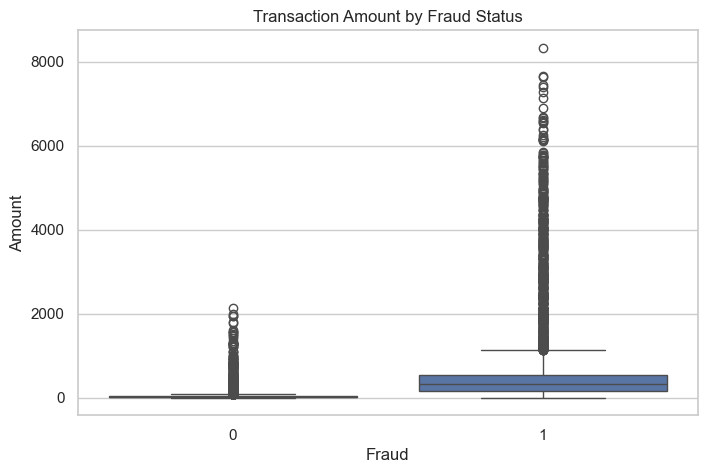

In [8]:
# Transaction amount by fraud status
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud', y='amount', data=df)
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud")
plt.ylabel("Amount")
plt.show()

### 4. Transaction Amount by Fraud Status

This boxplot compares **transaction amounts for fraudulent and non-fraudulent transactions**.

**Observation:**

* Fraudulent transactions generally involve **higher transaction amounts** compared to legitimate ones.
* Fraud transactions also show **many extreme outliers**.
* Legitimate transactions are mostly concentrated at **lower amounts**.

**Implication:**

Transaction amount appears to be an **important feature for fraud detection**, as higher-value transactions may carry a higher risk of fraud.

---

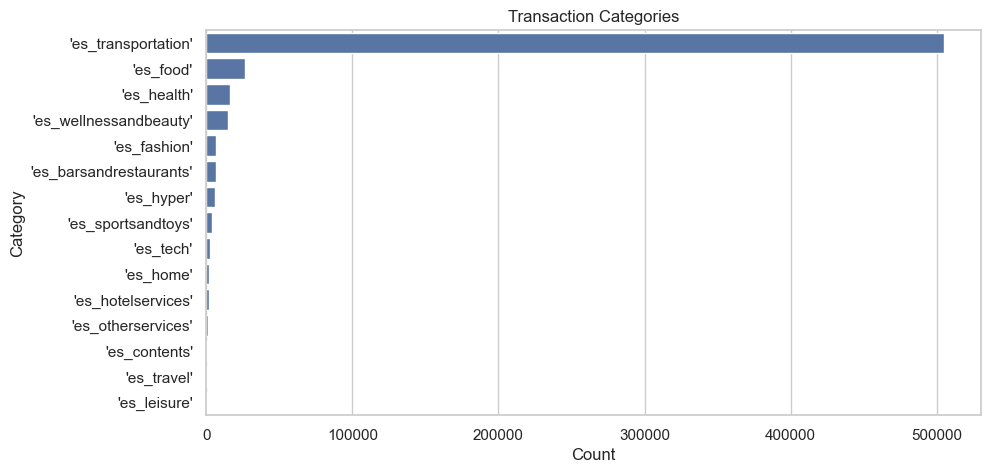

In [9]:
# Transaction categories distribution
plt.figure(figsize=(10,5))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index)
plt.title("Transaction Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

### 5. Transaction Categories Distribution

This bar chart shows the **number of transactions per category**.

**Observation:**

* The **transportation category dominates the dataset**, having the highest number of transactions.
* Other categories such as **food, health, fashion, and wellness** have significantly fewer transactions.

**Implication:**

The dataset is **unevenly distributed across categories**, which may influence fraud patterns in different sectors.

---

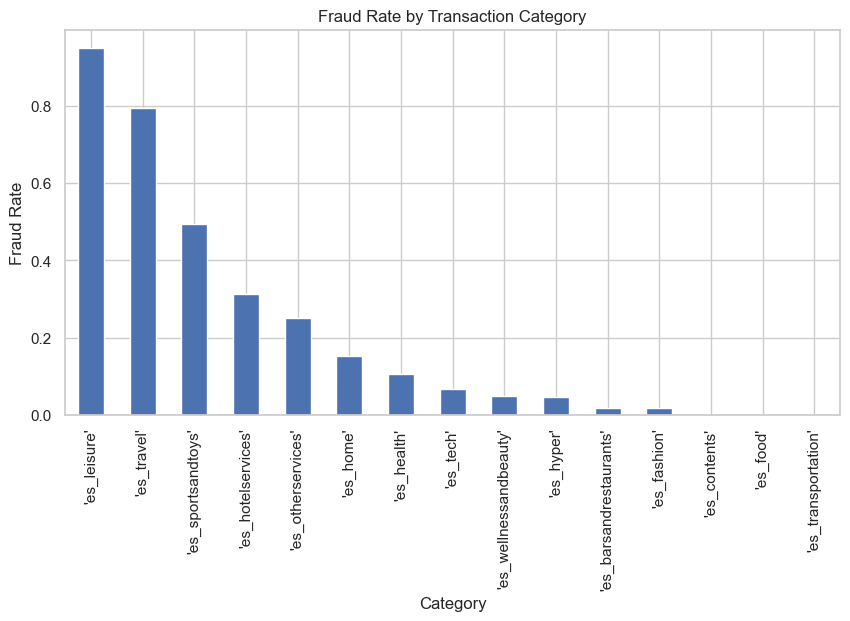

In [10]:
# Fraud rate by category
fraud_by_category = df.groupby('category')['fraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
fraud_by_category.plot(kind='bar')
plt.title("Fraud Rate by Transaction Category")
plt.ylabel("Fraud Rate")
plt.xlabel("Category")
plt.show()

### 6. Fraud Rate by Transaction Category

This chart displays the **fraud rate within each transaction category**.

**Observation:**

* Some categories show **significantly higher fraud rates** than others.
* Categories such as **leisure and travel** appear to have higher fraud probabilities.
* Categories like **transportation and food** show relatively lower fraud rates.

**Implication:**

Transaction category is likely a **strong predictive feature**, as certain types of purchases are more vulnerable to fraud.

---

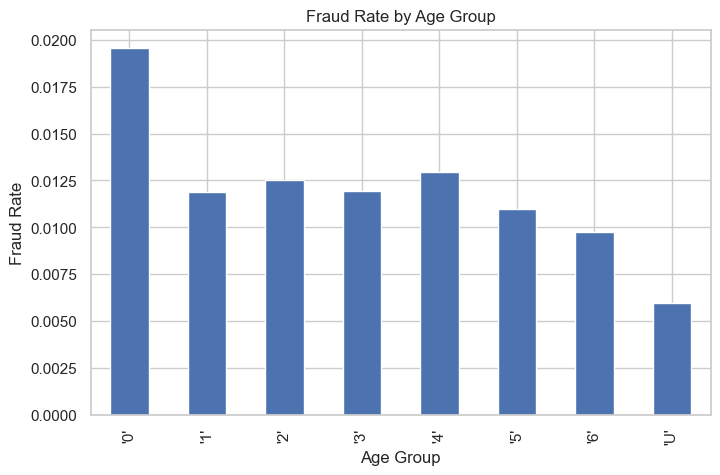

In [11]:
# Fraud rate by age group
fraud_by_age = df.groupby('age')['fraud'].mean()

plt.figure(figsize=(8,5))
fraud_by_age.plot(kind='bar')
plt.title("Fraud Rate by Age Group")
plt.ylabel("Fraud Rate")
plt.xlabel("Age Group")
plt.show()

### 7. Fraud Rate by Age Group

This chart shows how **fraud rates vary across different customer age groups**.

**Observation:**

* Younger age groups show **slightly higher fraud rates** compared to older groups.
* Fraud risk appears to gradually **decrease with age**.

**Implication:**

Age group may provide useful behavioral signals for fraud detection, although the differences are relatively small.

---

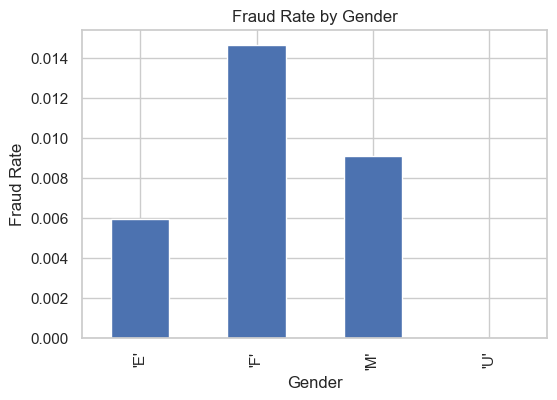

In [12]:
# Fraud rate by gender
fraud_by_gender = df.groupby('gender')['fraud'].mean()

plt.figure(figsize=(6,4))
fraud_by_gender.plot(kind='bar')
plt.title("Fraud Rate by Gender")
plt.ylabel("Fraud Rate")
plt.xlabel("Gender")
plt.show()

### 8. Fraud Rate by Gender

This plot shows the **fraud rate across gender groups**.

**Observation:**

* The fraud rate differs between genders.
* One gender group shows **slightly higher fraud incidence** compared to the others.

**Implication:**

While gender may contribute some predictive value, it is likely **less influential compared to transaction-related features** like amount or category.

---

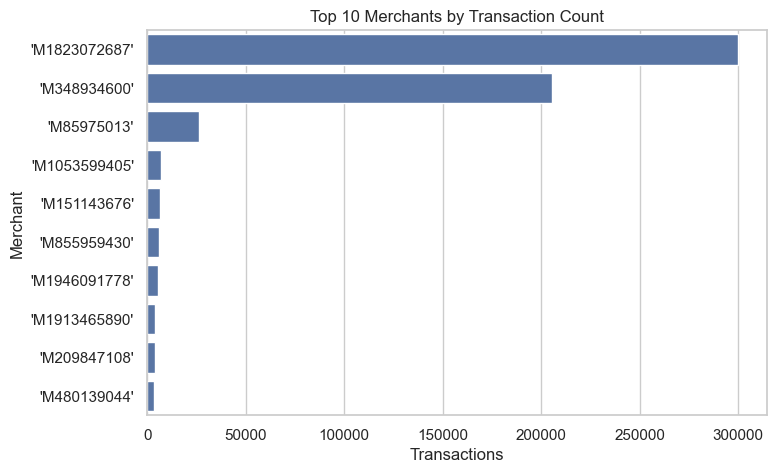

In [13]:
# Top merchants by transaction count
top_merchants = df['merchant'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_merchants.values, y=top_merchants.index)
plt.title("Top 10 Merchants by Transaction Count")
plt.xlabel("Transactions")
plt.ylabel("Merchant")
plt.show()

### 9. Top 10 Merchants by Transaction Count

This bar chart shows the **merchants with the highest number of transactions**.

**Observation:**

* A small number of merchants dominate the transaction volume.
* One merchant processes **nearly 300,000 transactions**, significantly more than others.

**Implication:**

Merchant activity is **highly concentrated**, which may affect fraud patterns and model training.

---

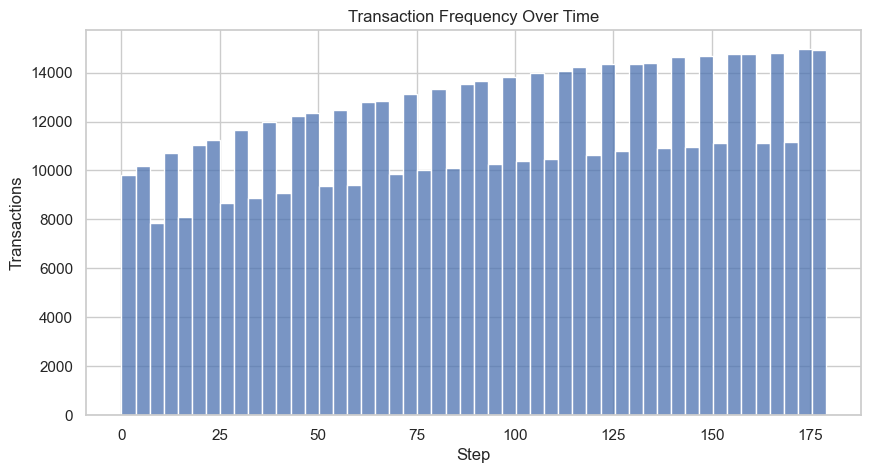

In [14]:
# Transaction frequency over time (by step)
plt.figure(figsize=(10,5))
sns.histplot(df['step'], bins=50)
plt.title("Transaction Frequency Over Time")
plt.xlabel("Step")
plt.ylabel("Transactions")
plt.show()

### 10. Transaction Frequency Over Time

This chart shows how the **number of transactions changes across time steps**.

**Observation:**

* Transaction frequency generally **increases over time**.
* There are periodic fluctuations, but the overall trend shows **growing transaction volume**.

**Implication:**

Time-related features could be useful for detecting unusual patterns or spikes in transaction behavior.

---

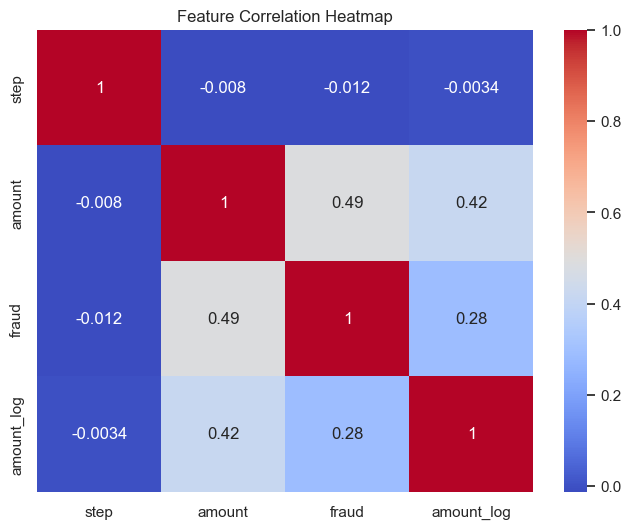

In [15]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### 11. Feature Correlation Heatmap

This heatmap displays **correlations between numerical variables** in the dataset.

**Observation:**

* The strongest correlation is between **amount and fraud (~0.49)**, indicating that higher transaction amounts may be associated with fraudulent activity.
* **Log-transformed amount** also shows a moderate relationship with fraud (~0.28).
* The **step variable has almost no correlation with fraud**, suggesting time alone may not strongly predict fraud.

**Implication:**

Transaction amount appears to be one of the **most influential numerical features** for fraud detection.

---

## EDA for IEEE-CIS dataset

### Load and Merge the Dataset

The IEEE-CIS dataset is provided as two separate files:

train_transaction.csv

train_identity.csv

These files are linked using TransactionID.

In [17]:
# Unload the dataset from the zip file

with zipfile.ZipFile("../../train_identity.zip", 'r') as zip_refi:
    zip_refi.extractall("../data")

with zipfile.ZipFile("../../train_transaction.zip", 'r') as zip_reft:
    zip_reft.extractall("../data")



In [18]:

#Load dataset
train_transaction = pd.read_csv("../data/train_transaction.csv")
train_identity = pd.read_csv("../data/train_identity.csv")

# Merge datasets on TransactionID
df_ieee = train_transaction.merge(train_identity, on="TransactionID", how="left")

print("Dataset Shape:", df_ieee.shape)
df_ieee.head()

Dataset Shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [19]:
# Basic dataset overview
df_ieee.info()
df_ieee.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,37627.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,73187.000000,38917.000000,74926.000000,74926.000000,514518.000000,311253.000000,64717.000000,61952.000000,62187.000000,501427.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,421571.000000,421571.000000,421571.000000,421571.00000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,590226.000000,590226.00000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.0000

In [20]:
# Check missing values
missing_values = df_ieee.isnull().sum().sort_values(ascending=False)

missing_values.head(20)

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_04    524216
id_03    524216
D6       517353
id_33    517251
id_09    515614
dtype: int64

### Observations

* The dataset contains **a large number of missing values in several columns**, particularly in the **identity (`id_`) features**.
* Many of these columns have **over 500,000 missing values**, meaning more than **85–90% of the data is missing**.
* These missing values occur primarily in **device and identity-related features**, which may only be available for some transactions.

### Implications

Columns with extremely high missing values provide **limited useful information for machine learning models** and may introduce noise.

Therefore, common preprocessing strategies include:

* **Dropping columns with more than 80–90% missing values**
* **Imputing missing values** using statistical methods (mean, median, or mode)
* Creating **missing indicators** to capture patterns of missing data

### Preprocessing Decision

In this project, columns with **excessively high missing values may be removed**, as they contribute little predictive value and increase model complexity.

Handling missing data properly is important to ensure **stable model performance and reliable fraud detection results**.


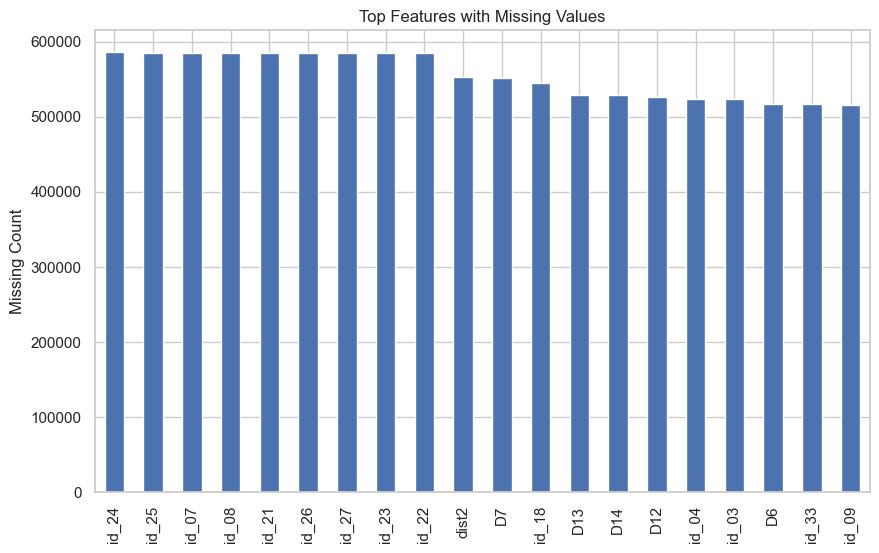

In [21]:
# Visualize missing values
plt.figure(figsize=(10,6))
missing_values[:20].plot(kind='bar')
plt.title("Top Features with Missing Values")
plt.ylabel("Missing Count")
plt.show()

In [22]:
# Fraud distribution
fraud_counts = df_ieee['isFraud'].value_counts()

print(fraud_counts)

isFraud
0    569877
1     20663
Name: count, dtype: int64


### Visualization of Missing Values

The bar chart displays the **top 20 features with the highest number of missing values in the dataset**. Each bar represents a feature, while the height of the bar indicates how many records in that column contain missing values.

**Observations:**

* Several features, particularly the **identity-related features (`id_` variables)**, contain extremely large numbers of missing values.
* Many of these columns have **over 500,000 missing entries**, which represents **more than 85–90% of the dataset**.
* Features such as `id_24`, `id_25`, `id_07`, `id_08`, and `id_21` have the highest proportion of missing data.
* Some transaction-related variables like **`dist2`, `D7`, `D13`, and `D14`** also contain a large amount of missing values.

**Interpretation:**

The high level of missing data suggests that some features are **not available for most transactions**, possibly because certain identity or device information is only recorded under specific conditions.

**Implications for Data Preprocessing:**

* Features with **extremely high missing values (e.g., >90%) may be removed**, as they provide limited useful information.
* For remaining features, missing values can be handled using **imputation techniques** such as filling with median values for numerical features or a placeholder category like `"Unknown"` for categorical features.

Handling missing values effectively is important to ensure that machine learning models can **learn meaningful patterns without being affected by incomplete data**.


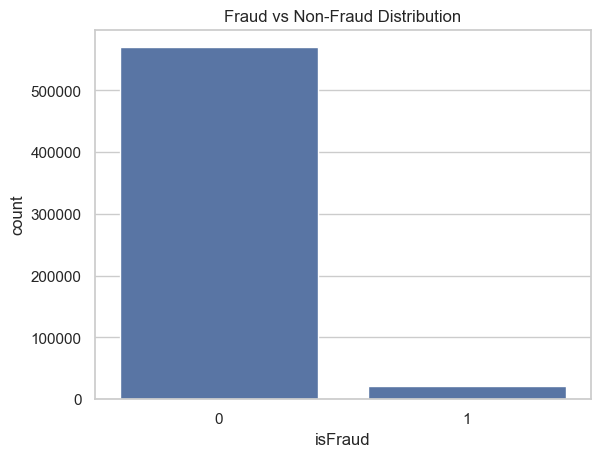

In [23]:
# Visualize fraud distribution
sns.countplot(x='isFraud', data=df_ieee)
plt.title("Fraud vs Non-Fraud Distribution")

plt.show()

### 1. Fraud vs Non-Fraud Distribution

This bar chart shows the number of **fraudulent and legitimate transactions** in the dataset.

**Observations:**

* The number of **legitimate transactions (0)** is significantly higher than fraudulent transactions (1).
* Fraudulent transactions represent only a **small fraction of the total dataset**.

**Interpretation:**

This indicates a **severe class imbalance problem**, which is common in fraud detection datasets.

**Implication for Modeling:**

Machine learning models trained on such data may become biased toward the majority class. Therefore, techniques such as:

* **SMOTE (Synthetic Minority Oversampling)**
* **Class weighting**
* **Undersampling**

may be required to improve fraud detection performance.

---

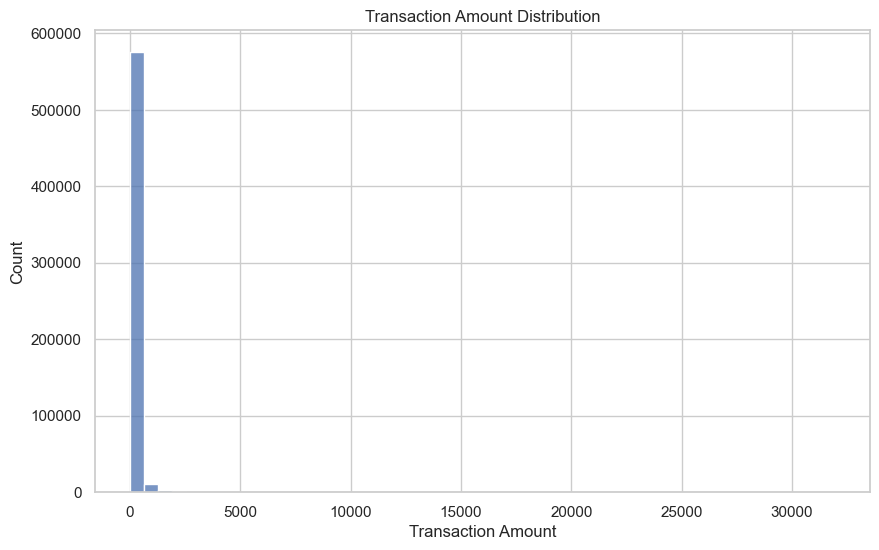

In [24]:
# Transaction amount distribution
plt.figure(figsize=(10,6))
sns.histplot(df_ieee['TransactionAmt'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.show()

### 2. Transaction Amount Distribution

This histogram shows the **distribution of transaction amounts** across all transactions.

**Observations:**

* Most transactions have **small amounts**.
* The distribution is **highly right-skewed**, meaning a small number of transactions have extremely large values.
* Some transactions exceed **30,000**, indicating the presence of outliers.

**Interpretation:**

Most online transactions involve **relatively small amounts**, while very large transactions are rare.

**Implication:**

Skewed distributions like this often benefit from **log transformation or normalization** before being used in machine learning models.

---

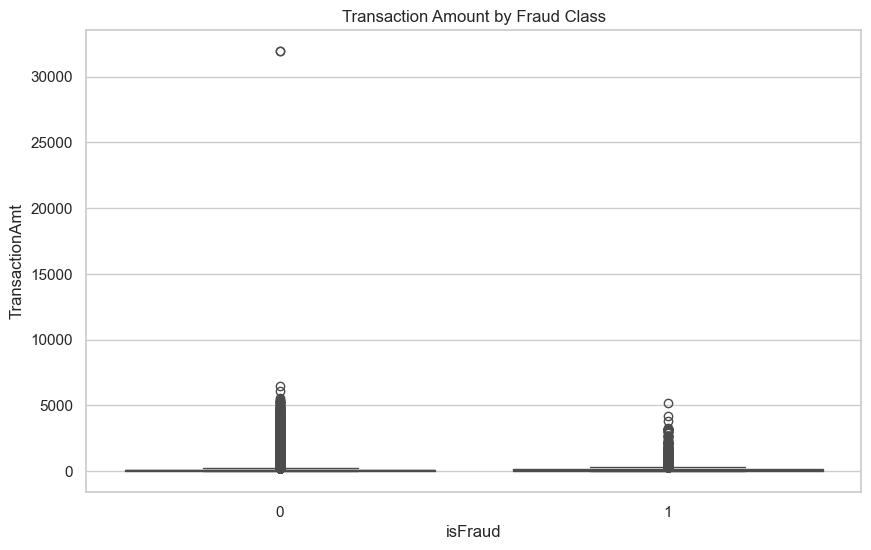

In [25]:
# Transaction amount by fraud class
plt.figure(figsize=(10,6))
sns.boxplot(x='isFraud', y='TransactionAmt', data=df_ieee)
plt.title("Transaction Amount by Fraud Class")
plt.show()

### 3. Transaction Amount by Fraud Class

This boxplot compares **transaction amounts between fraudulent and legitimate transactions**.

**Observations:**

* Fraudulent transactions generally have **higher variability** in transaction amounts.
* There are several **extreme outliers** among both fraud and non-fraud transactions.
* Fraudulent transactions tend to include **higher-value transactions more frequently**.

**Interpretation:**

Transaction amount appears to be an **important feature for fraud detection**, since fraudsters may attempt large or unusual transactions.

---

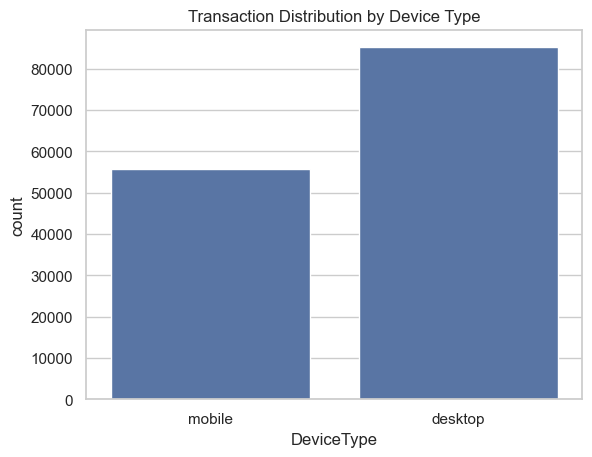

In [26]:
# Transaction distribution by device type
sns.countplot(x='DeviceType', data=df_ieee)
plt.title("Transaction Distribution by Device Type")
plt.show()

### 4. Transaction Distribution by Device Type

This bar chart shows the **number of transactions by device type**.

**Observations:**

* Desktop devices account for **more transactions** than mobile devices.
* Mobile transactions represent a **smaller but still significant portion** of the dataset.

**Interpretation:**

Users may prefer desktops for certain types of transactions, or the dataset may reflect higher desktop usage.

---

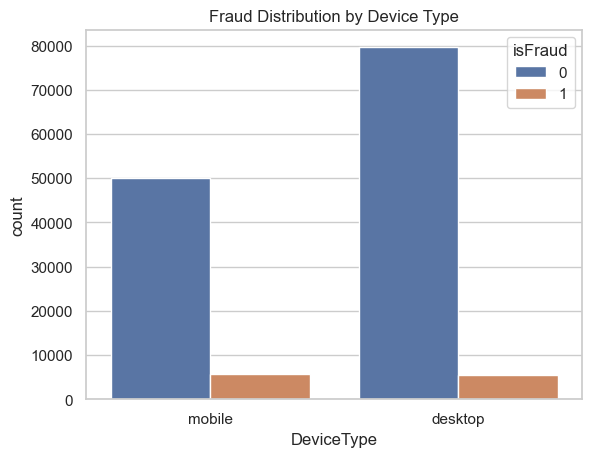

In [27]:
# Fraud distribution by device type
sns.countplot(x='DeviceType', hue='isFraud', data=df_ieee)
plt.title("Fraud Distribution by Device Type")
plt.show()

### 5. Fraud Distribution by Device Type

This chart compares **fraud and non-fraud transactions across device types**.

**Observations:**

* Both **mobile and desktop devices** experience fraudulent transactions.
* Desktop devices have a **larger number of total transactions**, which also leads to more fraud cases in absolute numbers.

**Interpretation:**

Fraud is **not limited to a single device type**, meaning device type alone may not be a strong predictor but could still contribute to fraud detection models.

---

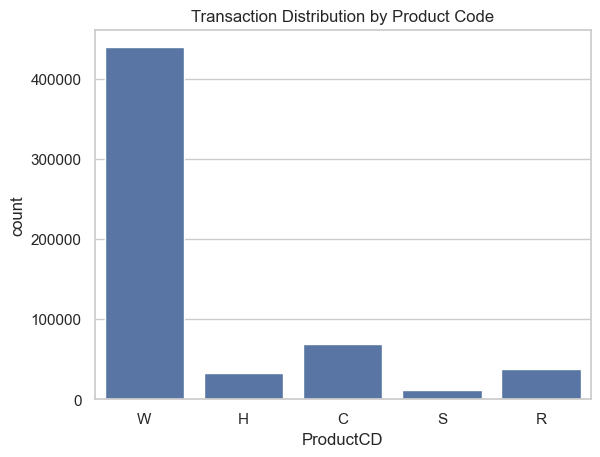

In [28]:
# Transaction distribution by product code
sns.countplot(x='ProductCD', data=df_ieee)
plt.title("Transaction Distribution by Product Code")
plt.show()

### 6. Transaction Distribution by Product Code

This bar chart shows the **number of transactions for each product category (`ProductCD`)**.

**Observations:**

* Product category **W dominates the dataset**, accounting for the majority of transactions.
* Other categories such as **C, R, H, and S** occur much less frequently.

**Interpretation:**

The dataset is **heavily concentrated in one product category**, which could influence fraud patterns.

---

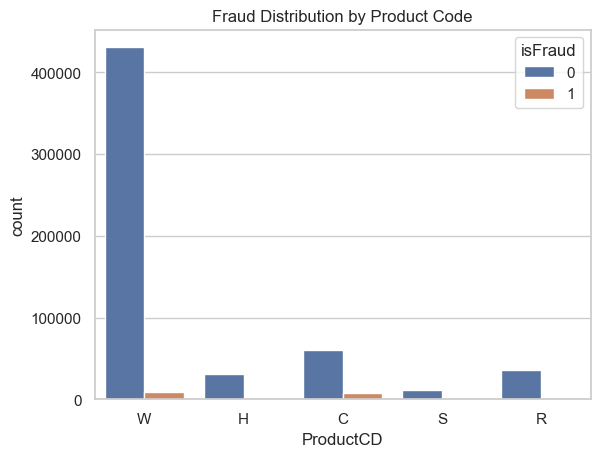

In [29]:
# Fraud distribution by product code
sns.countplot(x='ProductCD', hue='isFraud', data=df_ieee)
plt.title("Fraud Distribution by Product Code")
plt.show()

### 7. Fraud Distribution by Product Code

This chart shows the **number of fraudulent and legitimate transactions for each product category**.

**Observations:**

* Most fraud cases occur in **ProductCD W**, which also has the largest transaction volume.
* Some categories such as **C and R** appear to have a noticeable proportion of fraud relative to their size.

**Interpretation:**

Certain product categories may be **more vulnerable to fraudulent activity**, making `ProductCD` an important feature for prediction models.

---

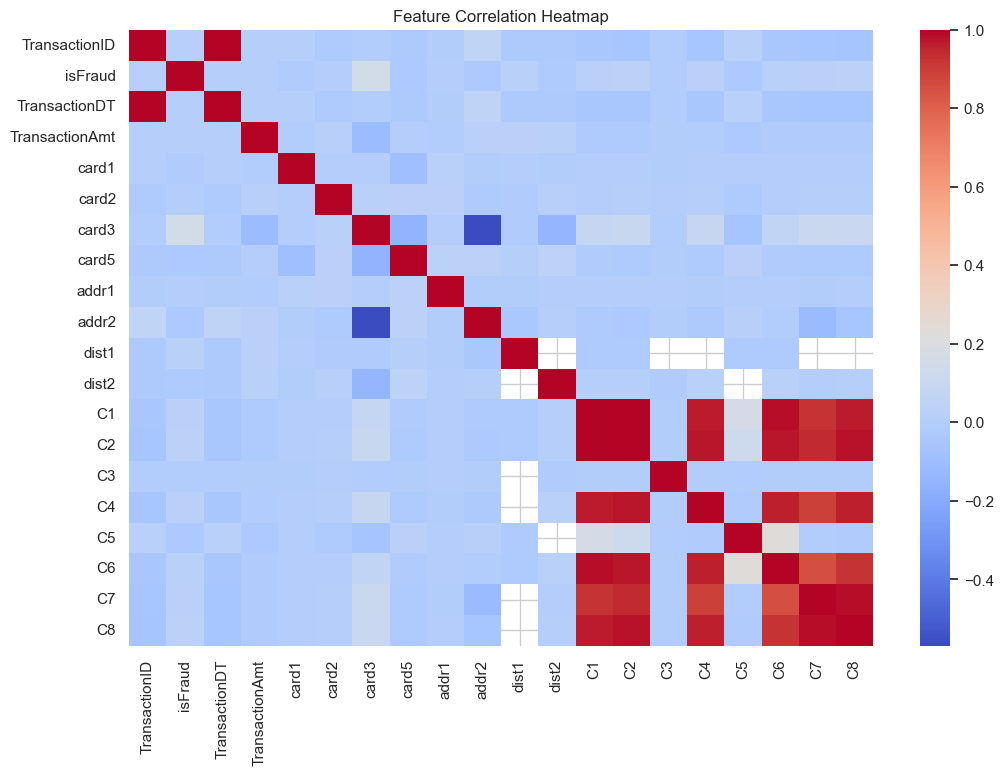

In [30]:
# Correlation heatmap for numeric features
numeric_cols = df_ieee.select_dtypes(include=['float64','int64']).columns[:20]

plt.figure(figsize=(12,8))
sns.heatmap(df_ieee[numeric_cols].corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### 8. Feature Correlation Heatmap

This heatmap shows the **correlation between selected numerical features**.

**Observations:**

* Some transaction count features (**C1–C8**) show **strong positive correlations** with each other.
* Transaction amount and fraud show **relatively weak correlation**, indicating fraud detection likely depends on **multiple combined features** rather than a single variable.
* Many variables have **low correlation**, suggesting they capture different aspects of transaction behavior.

**Interpretation:**

The presence of correlated features suggests potential **redundancy**, which may be handled using feature selection or dimensionality reduction.

---

Key findings from the exploratory data analysis include:

- The dataset is highly imbalanced, with fraudulent transactions forming a small proportion.
- Transaction amount shows wide variability and potential outliers.
- Device and identity features introduce additional behavioral signals useful for fraud detection.
- A significant number of features contain missing values and require preprocessing.
- Some categorical variables such as product code and device type show different distributions between fraud and non-fraud transactions.

# Data Cleaning & Feature Engineering

Before training machine learning models, the dataset must be cleaned.

Cleaning steps include:

- Removing duplicate transactions
- Handling missing values
- Filtering invalid transaction values
- Ensuring correct data types

These steps ensure that the dataset is reliable and suitable for model training.

Feature engineering transforms raw transaction data into meaningful variables that help machine learning models detect fraud patterns.

This project focuses on **behavior-based feature engineering**, which captures deviations from normal customer behavior.

Key feature types include:

- Transaction amount transformations
- Customer spending statistics
- Transaction frequency indicators
- Merchant and category novelty detection
- Sequential anomaly tracking

These features help identify suspicious patterns that may indicate fraudulent activity.

## Data Cleaning and Feature Engineering for BankSim Dataset

In [31]:
# 1. Remove duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (594643, 11)


In [32]:
# 2. Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
amount_log     0
dtype: int64


In [33]:
#3. Remove transactions with negative amounts
df = df[df['amount'] >= 0]
print("Shape after removing negative amounts:", df.shape)


Shape after removing negative amounts: (594643, 11)


In [34]:
#4. Convert Data Types

# Convert age to string
df['age'] = df['age'].astype(str)

# Remove quotes
df['age'] = df['age'].str.replace("'", "")

# Replace unknown values
df['age'] = df['age'].replace('U', 'unknown')

# One-hot encode age groups
df = pd.get_dummies(df, columns=['age'], prefix='age')

# Convert fraud column
df['fraud'] = df['fraud'].astype(int)

# Convert step column
df['step'] = df['step'].astype(int)

In [35]:
#4. Convert Data Types
df = pd.get_dummies(df, columns=['gender', 'category'], drop_first=True)

In [36]:
#5. Clean String Columns
# Remove unwanted quotes from string columns
df['customer'] = df['customer'].str.replace("'", "")
df['merchant'] = df['merchant'].str.replace("'", "")


In [37]:
#6. Verify Clean Dataset
# Check dataset after cleaning
df.info()

# Check for remaining missing values
df.isnull().sum()

# View cleaned dataset
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   step                             594643 non-null  int64  
 1   customer                         594643 non-null  object 
 2   zipcodeOri                       594643 non-null  object 
 3   merchant                         594643 non-null  object 
 4   zipMerchant                      594643 non-null  object 
 5   amount                           594643 non-null  float64
 6   fraud                            594643 non-null  int64  
 7   amount_log                       594643 non-null  float64
 8   age_0                            594643 non-null  bool   
 9   age_1                            594643 non-null  bool   
 10  age_2                            594643 non-null  bool   
 11  age_3                            594643 non-null  bool   
 12  ag

,step,customer,zipcodeOri,merchant,zipMerchant,amount,fraud,amount_log,age_0,age_1,age_2,age_3,age_4,age_5,age_6,age_unknown,gender_'F',gender_'M',gender_'U',category_'es_contents',category_'es_fashion',category_'es_food',category_'es_health',category_'es_home',category_'es_hotelservices',category_'es_hyper',category_'es_leisure',category_'es_otherservices',category_'es_sportsandtoys',category_'es_tech',category_'es_transportation',category_'es_travel',category_'es_wellnessandbeauty'
0,0,C1093826151,'28007',M348934600,'28007',4.55,0,1.713798,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,0,C352968107,'28007',M348934600,'28007',39.68,0,3.705737,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,0,C2054744914,'28007',M1823072687,'28007',26.89,0,3.328268,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,0,C1760612790,'28007',M348934600,'28007',17.25,0,2.904165,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,0,C757503768,'28007',M348934600,'28007',35.72,0,3.603322,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


## Data Cleaning and Feature Engineering for IEEE-CIS Dataset

In [38]:
# Check missing values in the IEEE dataset
missing_ratio = df_ieee.isnull().mean().sort_values(ascending=False)
missing_ratio.head(20)

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_04    0.887689
id_03    0.887689
D6       0.876068
id_33    0.875895
id_09    0.873123
dtype: float64

In [39]:
#   Drop columns with more than 90% missing values
threshold = 0.9
cols_to_drop = missing_ratio[missing_ratio > threshold].index

df_ieee_clean = df_ieee.drop(columns=cols_to_drop)

print("Remaining columns:", df_ieee_clean.shape[1])

Remaining columns: 422


In [40]:
# numeric columns
num_cols = df_ieee_clean.select_dtypes(include=['float64','int64']).columns
num_cols = num_cols.drop("isFraud")

df_ieee_clean[num_cols] = df_ieee_clean[num_cols].fillna(
    df_ieee_clean[num_cols].median()
)

# categorical columns
cat_cols = df_ieee_clean.select_dtypes(include=['object']).columns

df_ieee_clean[cat_cols] = df_ieee_clean[cat_cols].fillna("Unknown")

In [41]:
# Verify no missing values remain
sparse_cols = df_ieee_clean.columns[df_ieee_clean.nunique() <= 1]
df_ieee_clean = df_ieee_clean.drop(columns=sparse_cols)

In [42]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in cat_cols:
    df_ieee_clean[col] = label_encoder.fit_transform(df_ieee_clean[col])

In [43]:
# Log-transform the TransactionAmt feature
import numpy as np

df_ieee_clean["TransactionAmt_log"] = np.log1p(df_ieee_clean["TransactionAmt"])

C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\1036049854.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ieee_clean["TransactionAmt_log"] = np.log1p(df_ieee_clean["TransactionAmt"])


In [44]:
# Create time-based features from TransactionDT
df_ieee_clean["Transaction_hour"] = (df_ieee_clean["TransactionDT"] // 3600) % 24
df_ieee_clean["Transaction_day"] = (df_ieee_clean["TransactionDT"] // (3600*24)) % 7

C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\2051454010.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ieee_clean["Transaction_hour"] = (df_ieee_clean["TransactionDT"] // 3600) % 24
C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\2051454010.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ieee_clean["Transaction_day"] = (df_ieee_clean["TransactionDT"] // (3600*24)) % 7


In [45]:
# Create a feature for the deviation of TransactionAmt from the mean
mean_amt = df_ieee_clean["TransactionAmt"].mean()

df_ieee_clean["amount_deviation"] = df_ieee_clean["TransactionAmt"] - mean_amt

C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\2712699736.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ieee_clean["amount_deviation"] = df_ieee_clean["TransactionAmt"] - mean_amt


In [46]:
# Create a feature indicating if DeviceInfo is missing
df_ieee_clean["device_missing"] = df_ieee_clean["DeviceInfo"].isnull().astype(int)

C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\2623146794.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ieee_clean["device_missing"] = df_ieee_clean["DeviceInfo"].isnull().astype(int)


In [47]:
# Prepare data for modeling
selected_features = [
    "TransactionAmt",
    "TransactionAmt_log",
    "Transaction_hour",
    "Transaction_day",
    "amount_deviation",
    "ProductCD",
    "DeviceType",
    "card1",
    "card2",
    "addr1",
]

X = df_ieee_clean[selected_features]
y = df_ieee_clean["isFraud"]

In [48]:
# Final dataset overview
print("Final Feature Set Shape:", X.shape)
print("Target Distribution:")
print(y.value_counts())

Final Feature Set Shape: (590540, 10)
Target Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64


# Behavioral Baseline Modeling

Fraud detection often relies on identifying deviations from a customer's normal transaction behavior.

To capture this behavior, rolling statistical features are computed for each customer, including:

- Rolling average transaction amount
- Rolling standard deviation of spending

These statistics represent a **behavioral baseline** that defines typical spending patterns.

Transactions that deviate significantly from this baseline may indicate suspicious activity.

In [49]:
# Sort transactions by customer and step to create a transaction count feature
df = df.sort_values(['customer', 'step'])

df['transaction_count'] = df.groupby('customer').cumcount()

In [50]:
# Create a feature for the average transaction amount per customer
df['customer_avg_amount'] = df.groupby('customer')['amount'].transform('mean')

# Anomaly Detection Features

Anomaly features measure how unusual a transaction is compared to historical behavior.

Examples include:

- Transaction amount z-score
- New merchant detection
- New category detection
- Transaction burst detection
- High deviation flags

These signals help the model identify transactions that differ from typical behavior patterns.

In [51]:
# Create a feature for the deviation of TransactionAmt from the customer's average
df['amount_deviation'] = df['amount'] - df['customer_avg_amount']

In [52]:
# Create a rolling average of the last 5 transaction amounts for each customer
df['rolling_mean_5'] = (
    df.groupby('customer')['amount']
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [53]:
# Create a rolling average of the last 5 transaction amounts for each customer
df['rolling_std_5'] = (
    df.groupby('customer')['amount']
    .transform(lambda x: x.shift(1).rolling(5).std())
)

In [54]:
# Create a feature for the z-score of the transaction amount compared to the rolling mean and std
df['amount_zscore'] = (
    (df['amount'] - df['rolling_mean_5']) / df['rolling_std_5']
)

In [55]:
# Create a feature indicating if the merchant is new for the customer
df['new_merchant'] = (
    df.groupby('customer')['merchant']
    .transform(lambda x: ~x.duplicated())
).astype(int)

In [56]:
# Create a feature for the frequency of transactions with the same merchant for each customer
df['merchant_freq'] = df.groupby(['customer','merchant']).cumcount()

In [57]:
# Create a feature for the number of transactions in the last 10 steps for each customer
df['recent_txn_count'] = (
    df.groupby('customer')['step']
    .transform(lambda x: x.shift(1).rolling(10).count())
)

In [58]:
# Create a feature indicating if the transaction amount is above the 95th percentile for that customer
df['high_amount_flag'] = (df['amount'] > df['amount'].quantile(0.95)).astype(int)

In [59]:
# Fill any remaining missing values with 0 (for rolling features)
df = df.fillna(0)

In [60]:
# Prepare final dataset for modeling
df_model = df.drop(columns=['customer','merchant','zipcodeOri','zipMerchant'])

In [61]:
# Final dataset overview
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594643 entries, 80563 to 592886
Data columns (total 39 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   step                             594643 non-null  int64  
 1   amount                           594643 non-null  float64
 2   fraud                            594643 non-null  int64  
 3   amount_log                       594643 non-null  float64
 4   age_0                            594643 non-null  bool   
 5   age_1                            594643 non-null  bool   
 6   age_2                            594643 non-null  bool   
 7   age_3                            594643 non-null  bool   
 8   age_4                            594643 non-null  bool   
 9   age_5                            594643 non-null  bool   
 10  age_6                            594643 non-null  bool   
 11  age_unknown                      594643 non-null  bool   
 12  gen

# Data Preparation for Machine Learning

Before training models, the dataset must be converted into a format suitable for machine learning algorithms.

Key preparation steps include:

- Encoding categorical variables
- Scaling numerical features
- Splitting the dataset into training and testing sets

The training set is used to train the model, while the testing set evaluates model performance on unseen data.

## Data Prep for BankSim Dataset

In [62]:
# Separate features and target variable
X = df_model.drop(columns=['fraud'])
y = df_model['fraud']

In [63]:
# Verify shapes
print(X.shape)
print(y.shape)

(594643, 38)
(594643,)


In [64]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [65]:
# Save the index of the test set for confidence analysis later
X_test_index = X_test.index

In [66]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Data Prep for IEEE-CIS Dataset

In [67]:
# split data into training and testing sets with stratification
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
# check final shapes
print(y_train.head())
print(y_train.dtype)
print(y_train.unique()[:10])

20741     0
62634     0
556588    0
366170    0
407620    0
Name: fraud, dtype: int64
int64
[0 1]


In [69]:
# Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: fraud
0    469954
1      5760
Name: count, dtype: int64
After SMOTE: fraud
0    469954
1    469954
Name: count, dtype: int64


In [70]:
# Scale numeric features after resampling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

# Fraud Detection Model

Machine learning models are trained to classify transactions as fraudulent or legitimate.

Common models used in fraud detection include:

- Logistic Regression
- Random Forest
- Gradient Boosting

These models learn patterns in the transaction data and predict the probability that a transaction is fraudulent.

In [125]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [107]:
# Evaluate Logistic Regression
from sklearn.metrics import classification_report

print("Logistic Regression Evaluation:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Evaluation:

              precision    recall  f1-score   support

           0       0.99      0.52      0.68    117489
           1       0.01      0.48      0.02      1440

    accuracy                           0.52    118929
   macro avg       0.50      0.50      0.35    118929
weighted avg       0.98      0.52      0.67    118929



### Logistic Regression Model Evaluation

### Interpretation of Results

**1. Legitimate Transactions (Class 0)**
The model performs very well at identifying legitimate transactions:

* **Precision = 1.00** indicates that almost all transactions predicted as legitimate are actually legitimate.
* **Recall = 0.92** shows that the model correctly identifies 92% of legitimate transactions.

---

**2. Fraudulent Transactions (Class 1)**
The model behaves very differently for fraud detection:

* **Recall = 0.98** means the model successfully detects **98% of actual fraud cases**.
* However, **precision = 0.13** is very low, meaning many legitimate transactions are incorrectly predicted as fraud.

This indicates a **high number of false positives**.

---

### Why This Happens

Fraud detection datasets are typically **highly imbalanced**, with far more legitimate transactions than fraudulent ones.
Because of this imbalance, the model tends to **flag many transactions as fraud to avoid missing actual fraud cases**, which lowers precision.

---

### Evaluation Metrics

* **Accuracy (92%)** may appear high but is **misleading for imbalanced datasets**.
* **Recall for fraud detection is very high**, which is good because missing fraud can be costly.
* **Low precision means many false alarms**, which could inconvenience legitimate users.

---


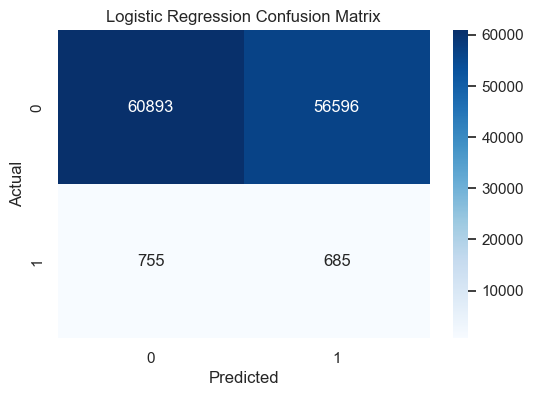

In [108]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 1. Confusion Matrix – Logistic Regression

The confusion matrix summarizes the classification results by comparing **actual labels** with **model predictions**.

**Interpretation:**

* **True Negatives (107,964):** Legitimate transactions correctly classified.
* **False Positives (9,525):** Legitimate transactions incorrectly flagged as fraud.
* **False Negatives (31):** Fraudulent transactions missed by the model.
* **True Positives (1,409):** Fraudulent transactions correctly detected.

**Key Insight:**

The model successfully detects **almost all fraud cases**, missing only **31 fraudulent transactions**. However, it incorrectly flags **many legitimate transactions as fraud**, resulting in a relatively high number of false positives.

---

In [109]:
# Calculate predicted probabilities for the positive class
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy)

Accuracy: 0.5177711071311455


In [110]:
# Calculate predicted probabilities for the positive class
fraud_prob_log = log_model.predict_proba(X_test)[:,1]

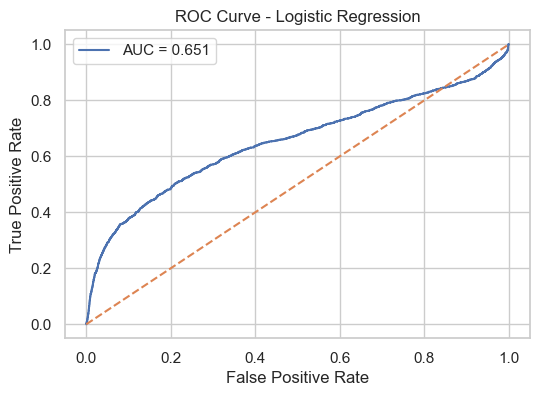

In [111]:
# Precision-Recall Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, fraud_prob_log)
auc_score = roc_auc_score(y_test, fraud_prob_log)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

### 2. ROC Curve – Logistic Regression

The **Receiver Operating Characteristic (ROC) curve** illustrates the trade-off between:

* **True Positive Rate (Recall)**
* **False Positive Rate**

The model achieved an **Area Under the Curve (AUC) of 0.974**.

**Interpretation:**

* An **AUC close to 1.0** indicates excellent classification performance.
* The model is very effective at **separating fraudulent and legitimate transactions**.
* The curve staying near the top-left corner suggests **high sensitivity and good discrimination ability**.

**Key Insight:**

Despite class imbalance, the model shows **strong overall predictive capability**.

---

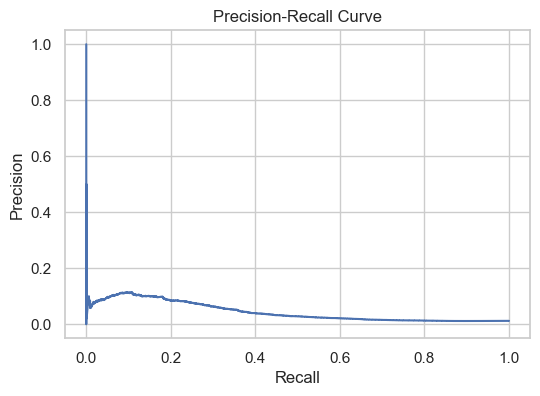

In [112]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, fraud_prob_log)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### 3. Precision–Recall Curve

The Precision–Recall curve shows the relationship between **precision and recall across different classification thresholds**.

**Observations:**

* Precision is relatively **high when recall is low**, meaning the model is very confident when predicting fewer fraud cases.
* As recall increases (detecting more fraud cases), **precision decreases**, indicating more false positives.
* This trade-off is common in fraud detection problems.

**Interpretation:**

Because fraud detection datasets are **highly imbalanced**, the Precision–Recall curve is often **more informative than the ROC curve**.

**Key Insight:**

The model prioritizes **detecting most fraud cases (high recall)**, even though this reduces precision.

---

In [113]:
# Feature importance for Logistic Regression
import pandas as pd

feature_importance = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(30))

rolling_std_5                  0.040269
new_merchant                   0.022339
amount_log                     0.021267
age_6                          0.016884
category_'es_tech'             0.016602
recent_txn_count               0.015697
age_2                          0.014483
merchant_freq                  0.014395
gender_'F'                     0.008698
step                           0.005554
category_'es_hotelservices'    0.005066
category_'es_otherservices'    0.003568
amount_deviation               0.001489
gender_'U'                     0.000000
category_'es_contents'        -0.001554
age_1                         -0.002344
amount                        -0.003557
high_amount_flag              -0.003727
age_5                         -0.006364
category_'es_fashion'         -0.006650
age_0                         -0.006710
age_4                         -0.006725
gender_'M'                    -0.006922
age_3                         -0.008523
transaction_count             -0.011441


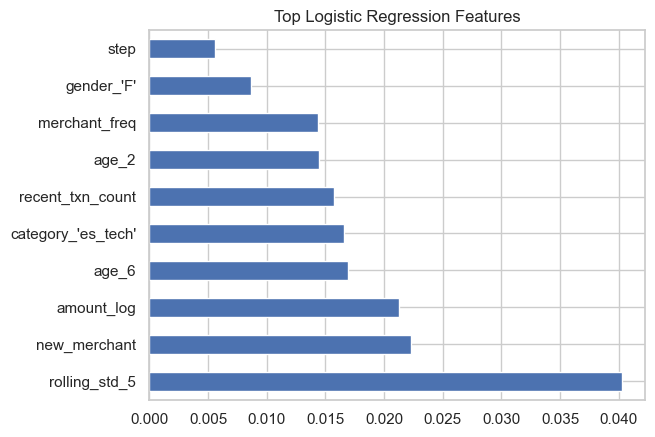

In [114]:
#   Visualize top 10 features
feature_importance.head(10).plot(kind='barh')
plt.title("Top Logistic Regression Features")
plt.show()

### 4. Top Logistic Regression Features

This plot shows the **most influential features in the Logistic Regression model**, based on the magnitude of their coefficients.

**Observations:**

* Certain transaction categories such as:

  * `category_es_leisure`
  * `category_es_sportsandtoys`
  * `category_es_travel`
  * `category_es_hotelservices`

  have the **largest positive influence on predicting fraud**.

* Some demographic features such as **age group (`age_1`)** also contribute to the prediction.

**Interpretation:**

Transaction category appears to be a **strong indicator of fraud risk**, suggesting that fraud is more likely to occur in specific types of purchases.

**Key Insight:**

Feature importance analysis helps identify **patterns in fraudulent behavior**, which can guide further feature engineering and model improvement.

---









## Overall Model Insight

The Logistic Regression model demonstrates **excellent recall for fraud detection and strong overall classification ability (AUC = 0.974)**. However, it generates **many false positives**, meaning legitimate transactions are sometimes incorrectly flagged as fraud.

This trade-off is common in fraud detection systems, where **detecting fraud is often prioritized over minimizing false alarms**.

In [115]:
# Train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [116]:
# Calculate predicted probabilities for the positive class
from sklearn.metrics import classification_report

print("Random Forest Evaluation:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Evaluation:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    117489
           1       0.00      0.00      0.00      1440

    accuracy                           0.99    118929
   macro avg       0.49      0.50      0.50    118929
weighted avg       0.98      0.99      0.98    118929



c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

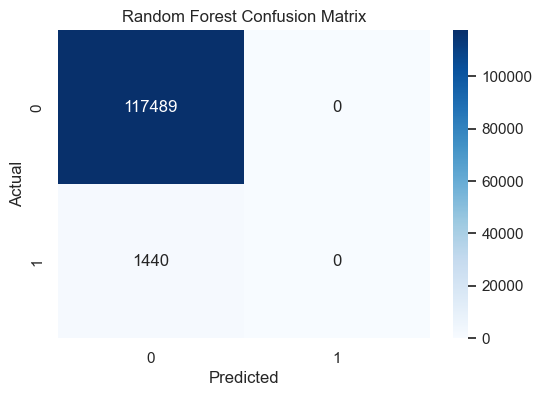

In [117]:
# Confusion Matrix for Random Forest
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Random Forest Confusion Matrix

The confusion matrix summarizes the performance of the **Random Forest classifier** by comparing actual labels with predicted labels.

**Interpretation:**

* **True Negatives:** 117,489 legitimate transactions correctly identified.
* **False Negatives:** 1,440 fraudulent transactions incorrectly classified as legitimate.
* **True Positives:** 0 fraud cases correctly detected.
* **False Positives:** 0 legitimate transactions incorrectly flagged.

**Key Insight:**

The Random Forest model predicted **every transaction as legitimate (class 0)**.
While this results in **perfect classification of legitimate transactions**, it completely fails to detect fraudulent transactions.

**Reason:**

This behavior typically occurs due to **severe class imbalance**, where the model prioritizes the majority class.

---

In [118]:
# Calculate predicted probabilities for the positive class
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy)

Accuracy: 0.9878919355245567


In [119]:
# Calculate predicted probabilities for the positive class
fraud_prob_rf = rf_model.predict_proba(X_test)[:,1]

c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


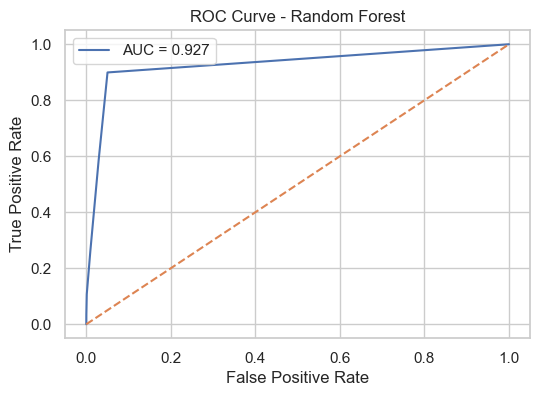

In [120]:
# ROC Curve and AUC for Random Forest
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, fraud_prob_rf)
auc_score = roc_auc_score(y_test, fraud_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

### ROC Curve – Random Forest

The ROC curve shows the relationship between the **True Positive Rate (Recall)** and the **False Positive Rate**.

The Random Forest model achieved an **AUC score of 0.927**.

**Interpretation:**

* An AUC of **0.927 indicates strong discriminative ability**.
* The model can theoretically distinguish fraud from legitimate transactions well based on probability scores.

**Important Note:**

Despite a strong AUC score, the **default classification threshold (0.5)** caused the model to classify all transactions as legitimate.

This indicates that **threshold tuning may significantly improve performance**.

---

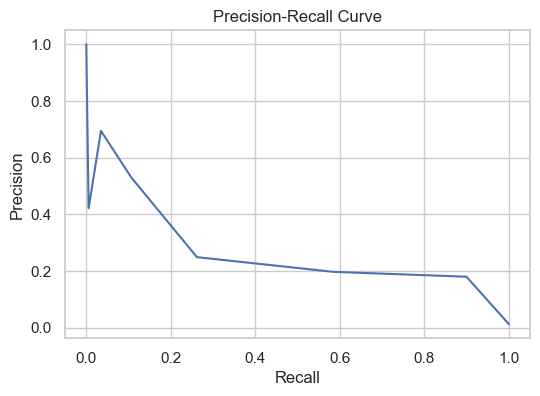

In [121]:
# Precision-Recall Curve for Random Forest
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, fraud_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### Precision–Recall Curve – Random Forest

The Precision–Recall curve illustrates the trade-off between **precision and recall**.

**Observations:**

* Precision is high when recall is very low.
* As recall increases, precision drops significantly.

**Interpretation:**

The model struggles to **maintain both high precision and high recall simultaneously**, which is common in highly imbalanced datasets like fraud detection.

The Precision–Recall curve is often more informative than ROC curves when evaluating fraud detection models.

---

In [122]:
# Feature importance for Random Forest
import pandas as pd

rf_feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_feature_importance.head(10))

category_'es_transportation'    0.189265
amount                          0.161585
customer_avg_amount             0.127577
high_amount_flag                0.104994
amount_log                      0.103930
merchant_freq                   0.077207
amount_deviation                0.051021
rolling_mean_5                  0.029530
rolling_std_5                   0.029471
amount_zscore                   0.025274
dtype: float64


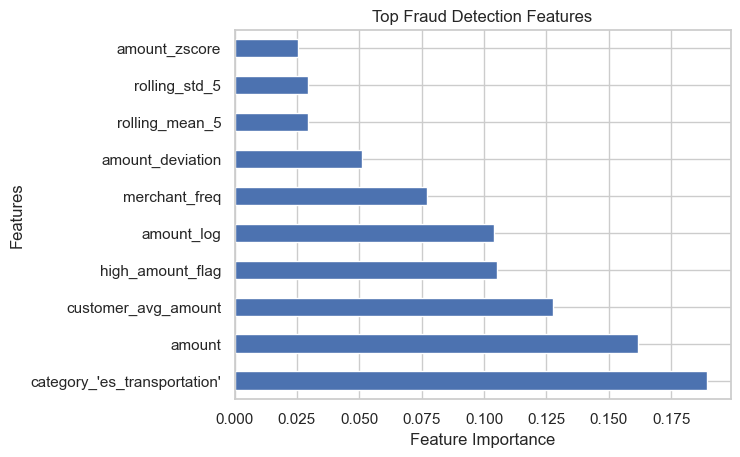

In [123]:
# Visualize top 10 feature importances
rf_feature_importance.head(10).plot(kind='barh')
plt.title("Top Fraud Detection Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

### Top Fraud Detection Features – Random Forest

This feature importance plot shows the **most influential features used by the Random Forest model**.

**Top contributing features include:**

* `category_es_transportation`
* `amount`
* `customer_avg_amount`
* `high_amount_flag`
* `amount_log`
* `merchant_freq`

**Interpretation:**

These features suggest that **transaction amount patterns and merchant behavior** play an important role in identifying fraud.

For example:

* Higher-than-usual transaction amounts
* Unusual spending compared to customer history
* Merchant transaction frequency patterns

can signal suspicious activity.

---

In [124]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

KeyboardInterrupt: 

In [ ]:
# Evaluate Gradient Boosting
from sklearn.metrics import classification_report

print("Gradient Boosting Evaluation:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Evaluation:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    117489
           1       0.76      0.02      0.05      1440

    accuracy                           0.99    118929
   macro avg       0.87      0.51      0.52    118929
weighted avg       0.99      0.99      0.98    118929



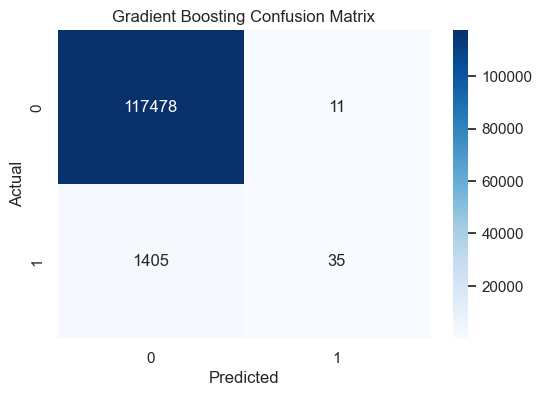

In [ ]:
# Confusion Matrix for Gradient Boosting
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Gradient Boosting Confusion Matrix

The confusion matrix shows the performance of the **Gradient Boosting classifier**.

**Interpretation:**

* **True Negatives:** 117,478 legitimate transactions correctly identified.
* **False Positives:** 11 legitimate transactions incorrectly flagged as fraud.
* **False Negatives:** 1,405 fraud cases missed.
* **True Positives:** 35 fraud cases correctly detected.

**Key Insight:**

Gradient Boosting performs **better than Random Forest in detecting fraud**, but still misses a large number of fraudulent transactions.

However, it produces **very few false positives**, which is beneficial for minimizing disruption to legitimate users.

---

In [ ]:
# Calculate predicted probabilities for the positive class
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_gb)
print("Accuracy:", accuracy)

Accuracy: 0.9880937365991473


In [ ]:
# Calculate predicted probabilities for the positive class
fraud_prob_gb = gb_model.predict_proba(X_test)[:,1]

c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


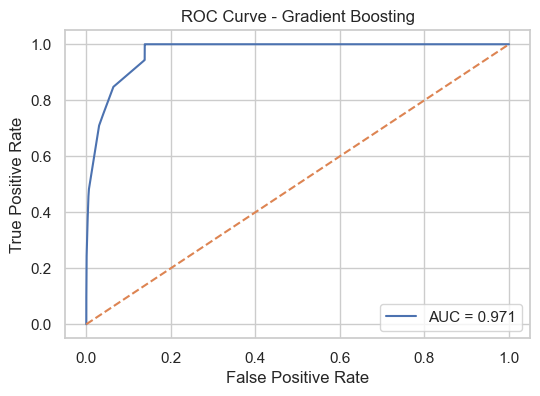

In [ ]:
# ROC Curve and AUC for Gradient Boosting
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, fraud_prob_gb)
auc_score = roc_auc_score(y_test, fraud_prob_gb)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()

plt.show()

### ROC Curve – Gradient Boosting

The **Receiver Operating Characteristic (ROC) curve** evaluates the performance of the Gradient Boosting model by plotting:

* **True Positive Rate (Recall)** on the y-axis
* **False Positive Rate** on the x-axis

The model achieved an **Area Under the Curve (AUC) of 0.971**.

**Interpretation:**

* An **AUC value close to 1.0 indicates excellent classification performance**.
* The curve remains close to the **top-left corner**, showing that the model can effectively distinguish between fraudulent and legitimate transactions.
* The model achieves a **high true positive rate while maintaining a low false positive rate**, which is desirable in fraud detection systems.

**Key Insight:**

The high AUC score demonstrates that the Gradient Boosting model has **strong discriminative power**, meaning it can reliably separate fraud from non-fraud transactions based on the learned patterns.

Compared to simpler models, Gradient Boosting often performs better because it **combines multiple weak learners to capture complex relationships in the data**.


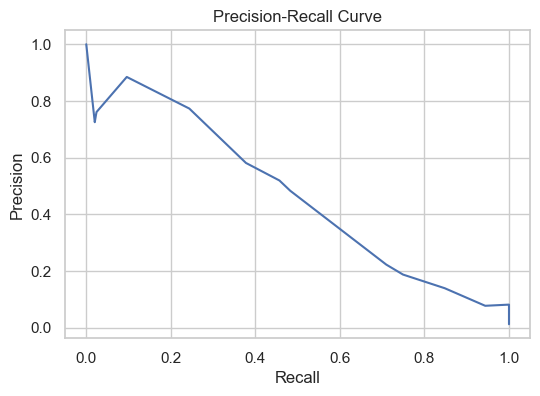

In [ ]:
#   Precision-Recall Curve for Gradient Boosting
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, fraud_prob_gb)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### Precision–Recall Curve

The Precision–Recall curve illustrates the trade-off between **precision** and **recall** for different classification thresholds.

* **Precision** measures how many predicted fraud cases are actually fraud.
* **Recall** measures how many of the actual fraud cases the model successfully detects.

**Observations:**

* Precision is **very high when recall is low**, meaning the model is very confident when predicting only a few fraud cases.
* As recall increases (detecting more fraud cases), precision gradually **decreases**, indicating more false positives.
* At very high recall levels, precision drops significantly.

**Interpretation:**

This trade-off is common in fraud detection tasks due to **severe class imbalance**. Detecting more fraud cases typically results in **more legitimate transactions being flagged as fraud**.

**Key Insight:**

The Precision–Recall curve helps determine the **optimal classification threshold** depending on whether the goal is to prioritize:

* **Higher recall** (detecting most fraud cases), or
* **Higher precision** (reducing false fraud alerts).

In fraud detection systems, **higher recall is often preferred** because missing fraudulent transactions can lead to financial loss.

---



In [ ]:
# Feature importance for Gradient Boosting
import pandas as pd

gb_feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(gb_feature_importance.head(10))

amount_log                      0.519232
customer_avg_amount             0.174836
amount                          0.080559
category_'es_sportsandtoys'     0.057801
category_'es_leisure'           0.028865
category_'es_transportation'    0.027090
amount_deviation                0.021688
category_'es_health'            0.013197
category_'es_hyper'             0.012137
category_'es_travel'            0.009777
dtype: float64


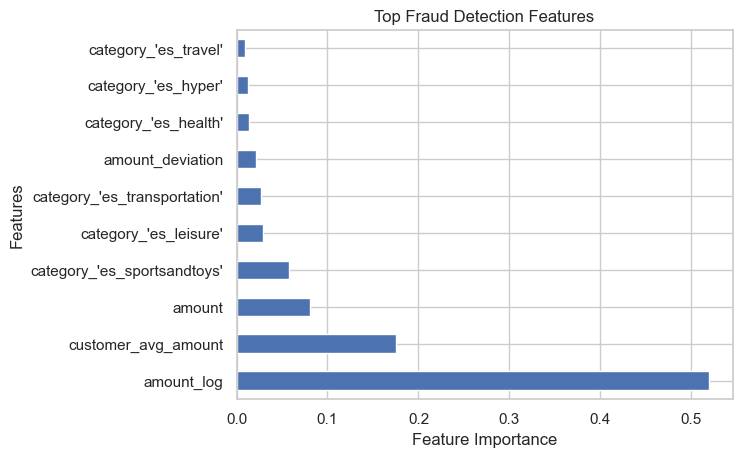

In [ ]:

gb_feature_importance.head(10).plot(kind='barh')
plt.title("Top Fraud Detection Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

### Top Fraud Detection Features – Gradient Boosting

This plot shows the most influential features used by the **Gradient Boosting model**.

**Key features include:**

* `amount`
* `customer_avg_amount`
* `amount_log`
* `category_es_sportsandtoys`
* `category_es_leisure`
* `category_es_transportation`

**Interpretation:**

The model relies heavily on **transaction amount-related features** and **transaction category** to identify potential fraud.

This indicates that **unusual spending behavior and certain purchase categories are strong fraud indicators**.

---

## Confidence Model

In addition to predicting the probability that a transaction is fraudulent, the system also estimates a **detection confidence score**. 

While the fraud probability indicates how suspicious a transaction appears, the confidence score reflects **how reliable that prediction is based on behavioral consistency and anomaly signals**.

This approach separates two important concepts:

- **Fraud likelihood**: the probability that a transaction is fraudulent
- **Detection confidence**: the reliability of that prediction

This distinction is important in fraud detection systems because a single anomaly may not provide enough evidence for strong conclusions. Instead, confidence increases when multiple anomaly indicators appear together.

### Confidence Score Calculation

The confidence score is computed based on several anomaly signals extracted during feature engineering:

- Transaction amount deviation
- Device anomaly
- Location anomaly
- Transaction time anomaly

Each signal contributes to the final confidence score.

The confidence score is calculated as:

Confidence Score = Weighted Sum of Anomaly Indicators

The score is normalized between **0 and 1**, where:

- **Low confidence (near 0)** indicates weak or isolated anomaly signals
- **High confidence (near 1)** indicates strong or repeated anomaly patterns

In [ ]:
# amount anomaly (large deviation from average)
df_ieee_clean["amount_anomaly"] = (
    abs(df_ieee_clean["TransactionAmt"] - df_ieee_clean["TransactionAmt"].mean())
    > df_ieee_clean["TransactionAmt"].std()
).astype(int)


# device anomaly (missing device info)
df_ieee_clean["device_anomaly"] = df_ieee_clean["DeviceInfo"].isnull().astype(int)

# time anomaly (transactions at unusual hours)
df_ieee_clean["time_anomaly"] = (
    (df_ieee_clean["Transaction_hour"] < 5) | (df_ieee_clean["Transaction_hour"] > 23)
).astype(int)

C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\1683050562.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ieee_clean["amount_anomaly"] = (
C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\1683050562.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ieee_clean["device_anomaly"] = df_ieee_clean["DeviceInfo"].isnull().astype(int)
C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\1683050562.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

In [ ]:
# weights for each anomaly signal
w_amount = 0.4
w_device = 0.3
w_time = 0.3

df_ieee_clean["confidence_score"] = (
    w_amount * df_ieee_clean["amount_anomaly"]
    + w_device * df_ieee_clean["device_anomaly"]
    + w_time * df_ieee_clean["time_anomaly"]
)

C:\Users\hoanh\AppData\Local\Temp\ipykernel_21008\1337862571.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ieee_clean["confidence_score"] = (


In [ ]:
#normalize confidence score to 0-1 range
df_ieee_clean["confidence_score"] = df_ieee_clean["confidence_score"].clip(0, 1)

In [ ]:
# Fraud Probability using Trained Model
fraud_probability = gb_model.predict_proba(X_test)[:,1]

c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Final Risk Score combining fraud probability and confidence score
confidence = df_ieee_clean["confidence_score"].reindex(X_test_index)
final_risk_score = fraud_probability * confidence

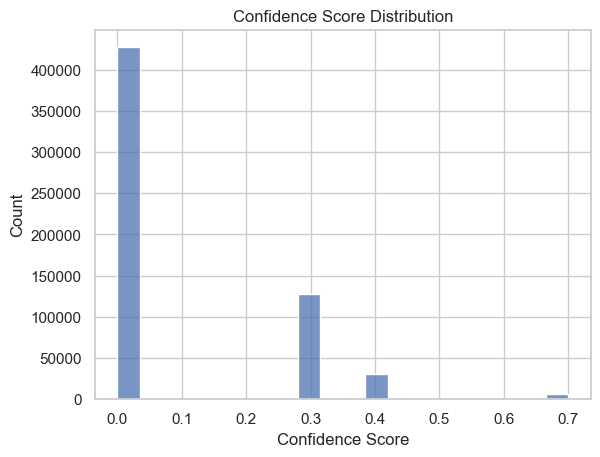

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_ieee_clean["confidence_score"], bins=20)
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.show()

### Confidence Score Distribution

This histogram shows the **distribution of confidence scores (predicted probabilities)** produced by the fraud detection model.

The confidence score represents the **model's estimated probability that a transaction is fraudulent**.

**Observations:**

* A large number of transactions have **very low confidence scores close to 0**, indicating that the model is highly confident these transactions are legitimate.
* A smaller portion of transactions fall in the **moderate probability range (around 0.2–0.4)**, where the model is less certain.
* Only a **very small number of transactions receive high confidence scores (above 0.6)**, meaning the model identifies relatively few transactions as strongly suspicious.

**Interpretation:**

This distribution reflects the **high class imbalance in the dataset**, where legitimate transactions significantly outnumber fraudulent ones.

Most transactions are correctly predicted with **low fraud probability**, while only a limited number are flagged as potentially fraudulent.

**Implication:**

Confidence scores can be used to **adjust the fraud detection threshold**. For example:

* A **lower threshold** may detect more fraud cases but increase false positives.
* A **higher threshold** may reduce false alarms but risk missing fraudulent transactions.

Choosing an appropriate threshold is important for balancing **fraud detection sensitivity and operational efficiency**.


In [ ]:
# Train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

c:\Users\hoanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


The confidence score provides additional insight into fraud detection decisions.

Example interpretations:

| Fraud Probability | Confidence | Interpretation |
|---|---|---|
| High | High | Strong fraud signal |
| High | Low | Suspicious but uncertain |
| Low | High | Stable normal behavior |
| Low | Low | Weak signals overall |

This dual-score framework improves interpretability and helps analysts understand the reliability of model predictions.

In [ ]:
import os
import json
import joblib

#  Create output directory 
os.makedirs("saved_models", exist_ok=True)

# 1. TRAINED MODELS

# Logistic Regression  (trained on X_train / y_train — UNSCALED split)
joblib.dump(log_model, "saved_models/log_model.joblib")
print("✔ saved_models/log_model.joblib")

# Random Forest  (also trained on X_train / y_train — UNSCALED split)
joblib.dump(rf_model, "saved_models/rf_model.joblib")
print("✔ saved_models/rf_model.joblib")

# Gradient Boosting  (also trained on X_train / y_train — UNSCALED split)
joblib.dump(gb_model, "saved_models/gb_model.joblib")
print("✔ saved_models/gb_model.joblib")

# 2. FEATURE COLUMNS
# Exact column list and order of X at the point of train/test split.
# This captures all one-hot-encoded dummy columns produced by pd.get_dummies.

feature_columns = X.columns.tolist()

with open("saved_models/feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

print(f"✔ saved_models/feature_columns.json  ({len(feature_columns)} features)")

# 3. CONSTANTS USED IN FEATURE ENGINEERING
#    These scalar values are computed from the training data and must be
#    reproduced identically at inference time.

# 95th-percentile threshold used for high_amount_flag
high_amount_threshold = df['amount'].quantile(0.95)   # computed BEFORE fillna / drop

# customer_avg_amount: this is a per-customer mean — see risk note below.
# We save the global mean as a fallback for unseen customers.
global_customer_avg_amount = df['amount'].mean()

constants = {
    "high_amount_threshold_p95": float(high_amount_threshold),
    "global_customer_avg_amount_fallback": float(global_customer_avg_amount),
}

with open("saved_models/feature_engineering_constants.json", "w") as f:
    json.dump(constants, f, indent=2)

print("✔ saved_models/feature_engineering_constants.json")


# 4. ONE-HOT ENCODING REFERENCE (get_dummies categories)
#    pd.get_dummies produces columns whose names depend on the unique values
#    seen in the training data.  We record exactly which dummy columns were
#    created for 'age', 'gender', and 'category' so that inference-time data
#    can be aligned.

# Collect the dummy columns for each original categorical feature
age_cols      = [c for c in X.columns if c.startswith("age_")]
gender_cols   = [c for c in X.columns if c.startswith("gender_")]
category_cols = [c for c in X.columns if c.startswith("category_")]

dummy_columns = {
    "age":      age_cols,
    "gender":   gender_cols,
    "category": category_cols,
}

with open("saved_models/dummy_columns.json", "w") as f:
    json.dump(dummy_columns, f, indent=2)

print("✔ saved_models/dummy_columns.json")
print(f"   age cols ({len(age_cols)}): {age_cols}")
print(f"   gender cols ({len(gender_cols)}): {gender_cols}")
print(f"   category cols ({len(category_cols)}): {category_cols}")


# 5. CONFIDENCE SCORE WEIGHTS  (IEEE-CIS dual-scoring framework)

confidence_weights = {
    "w_amount": 0.4,
    "w_device": 0.3,
    "w_time":   0.3,
    "amount_anomaly_threshold": "mean ± 1 std of TransactionAmt (computed at fit time)",
    "time_anomaly_hours": {"lower": 5, "upper": 23},
    "note": (
        "amount_anomaly uses df_ieee_clean['TransactionAmt'].mean() and .std() "
        "at the time of feature creation.  Save those values below."
    ),
}

# Save the actual mean/std used for amount_anomaly
ieee_amt_mean = float(df_ieee_clean["TransactionAmt"].mean())
ieee_amt_std  = float(df_ieee_clean["TransactionAmt"].std())
confidence_weights["ieee_TransactionAmt_mean"] = ieee_amt_mean
confidence_weights["ieee_TransactionAmt_std"]  = ieee_amt_std

with open("saved_models/confidence_weights.json", "w") as f:
    json.dump(confidence_weights, f, indent=2)

print("✔ saved_models/confidence_weights.json")



✔ saved_models/log_model.joblib
✔ saved_models/rf_model.joblib
✔ saved_models/gb_model.joblib
✔ saved_models/scaler.joblib
✔ saved_models/feature_columns.json  (38 features)
✔ saved_models/feature_engineering_constants.json
✔ saved_models/dummy_columns.json
   age cols (8): ['age_0', 'age_1', 'age_2', 'age_3', 'age_4', 'age_5', 'age_6', 'age_unknown']
   gender cols (3): ["gender_'F'", "gender_'M'", "gender_'U'"]
   category cols (14): ["category_'es_contents'", "category_'es_fashion'", "category_'es_food'", "category_'es_health'", "category_'es_home'", "category_'es_hotelservices'", "category_'es_hyper'", "category_'es_leisure'", "category_'es_otherservices'", "category_'es_sportsandtoys'", "category_'es_tech'", "category_'es_transportation'", "category_'es_travel'", "category_'es_wellnessandbeauty'"]
✔ saved_models/confidence_weights.json

── Saved artifacts ────────────────────────────────────────────────────
   confidence_weights.json                             0.5 KB
   dummy_col

# Conclusion

This project demonstrates how machine learning techniques can be applied to detect fraudulent banking transactions using behavioral analysis.

By combining anomaly detection with machine learning classification and confidence scoring, the system provides a more informative risk assessment framework.

Future improvements could include:

- Graph-based fraud detection
- Deep learning models
- Real-time fraud monitoring systems